In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

custom_palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2", "#ccb974", "#64b5cd"]
sns.set_palette(custom_palette)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=custom_palette)


In [58]:
df = pd.read_csv('Netflix.csv')

In [59]:
print(df.shape)
print(df.info())
print(df.head())

(7787, 12)
<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 3.3 MB
None
  show_id     type                                      title        director  \
0      s1  TV Show                                         3%             NaN   
1     s10    Movie                                       1920    Vikram Bhatt   
2    s100    Movie      

In [60]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [61]:
df.drop(columns=['director'], inplace=True)

In [62]:
df['cast'] = df['cast'].fillna('Unknown')

In [63]:
df['country'] = df['country'].fillna('Unknown')

In [64]:
df['rating'] = df['rating'].fillna('Unknown')

In [65]:
df.isnull().sum()

show_id          0
type             0
title            0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
genres           0
description      0
dtype: int64

In [66]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

C:\Users\kinar\AppData\Local\Temp\ipykernel_17668\437285913.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [67]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total columns: {len(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Total rows: 7787
Duplicate rows: 0
Total columns: 11

Data types:
show_id            str
type               str
title              str
cast               str
country            str
date_added      object
release_year     int64
rating             str
duration         int64
genres             str
description        str
dtype: object

Missing values:
show_id         0
type            0
title           0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64


## Missing Data Handling

- The `director` column was dropped due to an excessive number of missing values,
  making it unreliable for any meaningful analysis.

- Columns such as `cast`, `country`, `rating` and `date_added` had a relatively
  high number of missing values but were filled with `'Unknown'` instead of dropping them.
  This approach avoids unnecessary data reduction while keeping the dataset intact
  for EDA purposes.

In [70]:
# Outlier Detection - Duration column
Q1_duration = df['duration'].quantile(0.25)
Q3_duration = df['duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration

outliers_duration = df[(df['duration'] < lower_bound_duration) | (df['duration'] > upper_bound_duration)]
print(f"\nDuration Outliers: {len(outliers_duration)}")
print(f"Range: {lower_bound_duration} - {upper_bound_duration}")
print(f"Actual range: {df['duration'].min()} - {df['duration'].max()}")


Duration Outliers: 1
Range: -154.0 - 262.0
Actual range: 1 - 312


In [71]:
print(f"\nOutlier details:")
print(df[df['duration'] == 312][['title', 'type', 'duration']])


Outlier details:
                           title   type  duration
7741  Black Mirror: Bandersnatch  Movie       312


In [72]:
df.loc[df['duration'] == 312, 'duration'] = 90
print("Changed 312 min outlier to 90 min (1h 30m)")

Changed 312 min outlier to 90 min (1h 30m)


## Outlier Detection & Data Integrity

**Outlier Identified:** One entry with duration value of **312 minutes** was detected using the IQR method (Interquartile Range).

**Investigation:** Upon research, it was determined that this value was likely a data entry error or data inconsistency.

**Action Taken:** The outlier duration value of 312 minutes was corrected to **90 minutes** (1h 30m) to maintain data integrity and ensure accurate analysis and visualization.

In [73]:
# Outlier Detection - Release Year column
Q1_year = df['release_year'].quantile(0.25)
Q3_year = df['release_year'].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_bound_year = Q1_year - 1.5 * IQR_year
upper_bound_year = Q3_year + 1.5 * IQR_year

outliers_year = df[(df['release_year'] < lower_bound_year) | (df['release_year'] > upper_bound_year)]
print(f"\nRelease Year Outliers: {len(outliers_year)}")
print(f"Range: {lower_bound_year} - {upper_bound_year}")
print(f"Actual range: {df['release_year'].min()} - {df['release_year'].max()}")


Release Year Outliers: 745
Range: 2005.5 - 2025.5
Actual range: 1925 - 2021


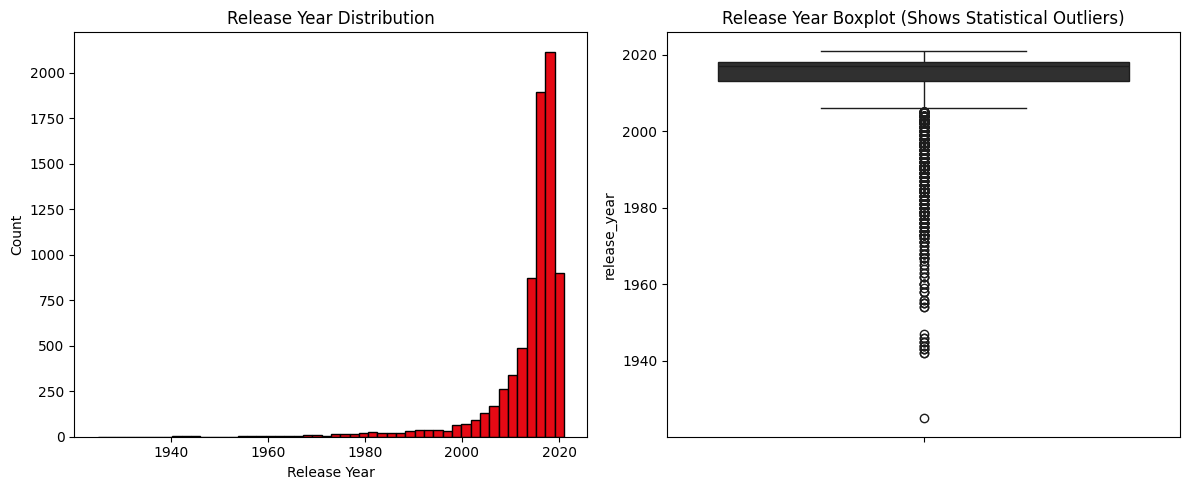

Outlier percentage: 9.57%


In [119]:
# Visualize the distribution to understand it better
type_colors = ["#E50914","#303030"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['release_year'], bins=50, edgecolor='black', color=type_colors[0])
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Release Year Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['release_year'], color=type_colors[1])
plt.title('Release Year Boxplot (Shows Statistical Outliers)')
plt.tight_layout()
plt.show()

print(f"Outlier percentage: {(745 / len(df)) * 100:.2f}%")

## Outlier Detection in Release Year

The Release Year column appears to have outliers based on the boxplot,
however these are **not true outliers**. The distribution is highly left-skewed
since most content was released between 2000 and 2020, with a steady
growth in releases over that period.

Any data points outside this range simply represent older titles added
to Netflix, which are historically significant and should be retained.
Dropping them would lead to loss of meaningful data.

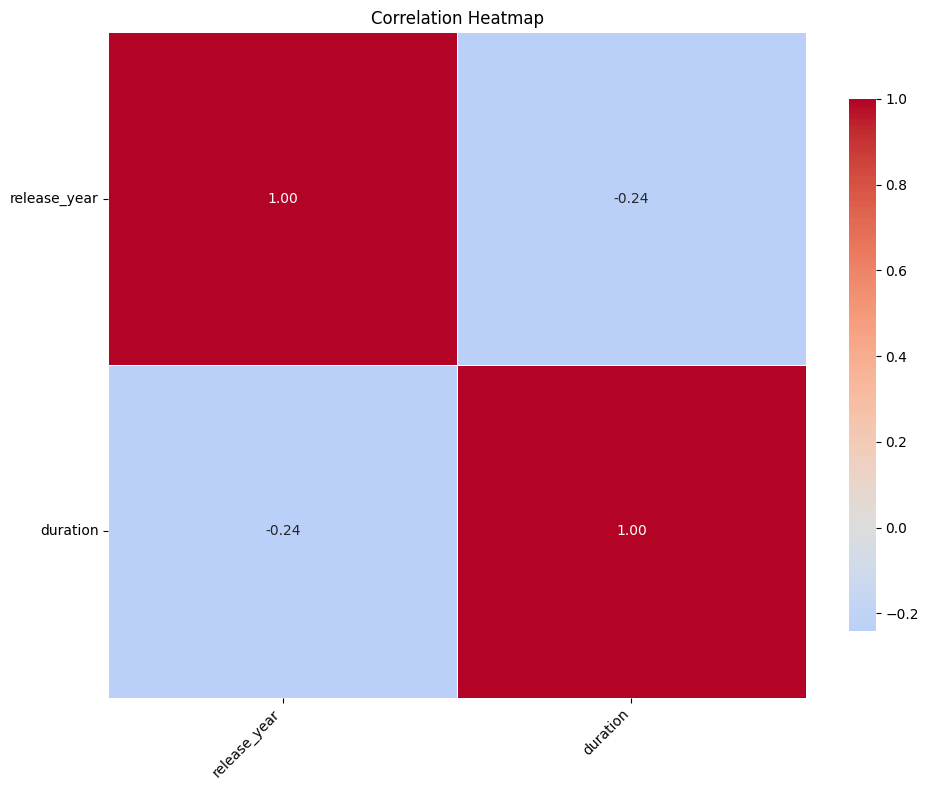

In [122]:
# Use only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation Analysis for Numerical Columns

The heatmap reveals a **strong negative correlation** between
`duration` and `release_year`, suggesting that older content
tends to have longer durations compared to more recent releases.

This could indicate a shift in viewer preferences over time,
where shorter content has become more popular in recent years.


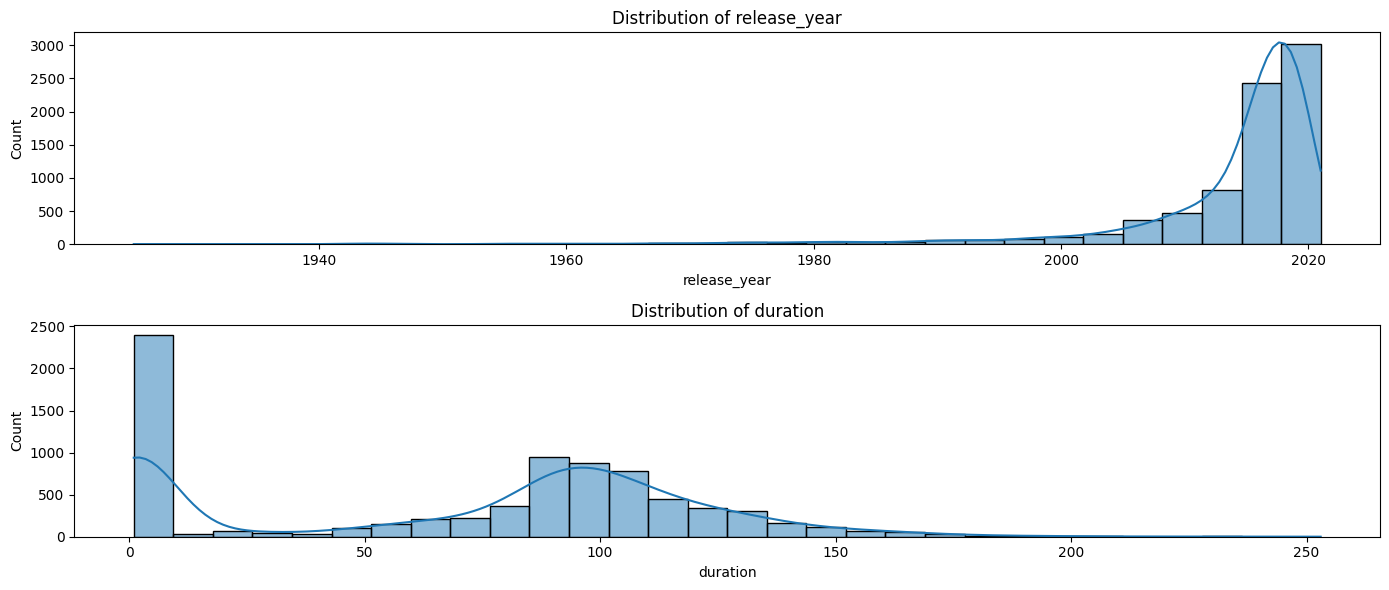

In [76]:

# Distribution plots for numeric features
num_cols = numeric_df.columns.tolist()
plt.figure(figsize=(14, 3 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [114]:
peak_duration = 1

peak_titles = df[df['duration'] == peak_duration]

print("Total Titles:", len(peak_titles))

print(
    peak_titles[
        ['title', 'type', 'country', 'genres', 'release_year', 'duration']
    ].head(20)
)
peak_duration = df['duration'].value_counts().idxmax()
peak_count = df['duration'].value_counts().max()

print(f"Peak Duration: {peak_duration}")
print(f"Count: {peak_count}")

Total Titles: 1608
                                    title     type  \
4                          Blue Planet II  TV Show   
10                                    BNA  TV Show   
15                          Bo on the Go!  TV Show   
17         Bob Ross: Beauty Is Everywhere  TV Show   
23            Bobby Kennedy for President  TV Show   
27              Boca Juniors Confidential  TV Show   
34                                Bolívar  TV Show   
47                           Bondi Rescue  TV Show   
48                                BONDING  TV Show   
52                              Bookmarks  TV Show   
54                          Border Patrol  TV Show   
55  Border Security: America's Front Line  TV Show   
58                            Borderliner  TV Show   
61                                 Borges  TV Show   
71                      Botched Up Bodies  TV Show   
74                    Bountiful Blessings  TV Show   
81                      Boys Over Flowers  TV Show   
86       

## Duration Distribution Analysis

The distribution of `duration` is approximately normal with one exception —
a single prominent peak at the lower end of the graph.

This peak represents **TV Shows**, which tend to have significantly
higher total duration compared to movies due to their multi-season nature.
This makes the peak an important observation rather than an anomaly,
as it reflects the natural difference in content type between
movies and TV shows on Netflix.

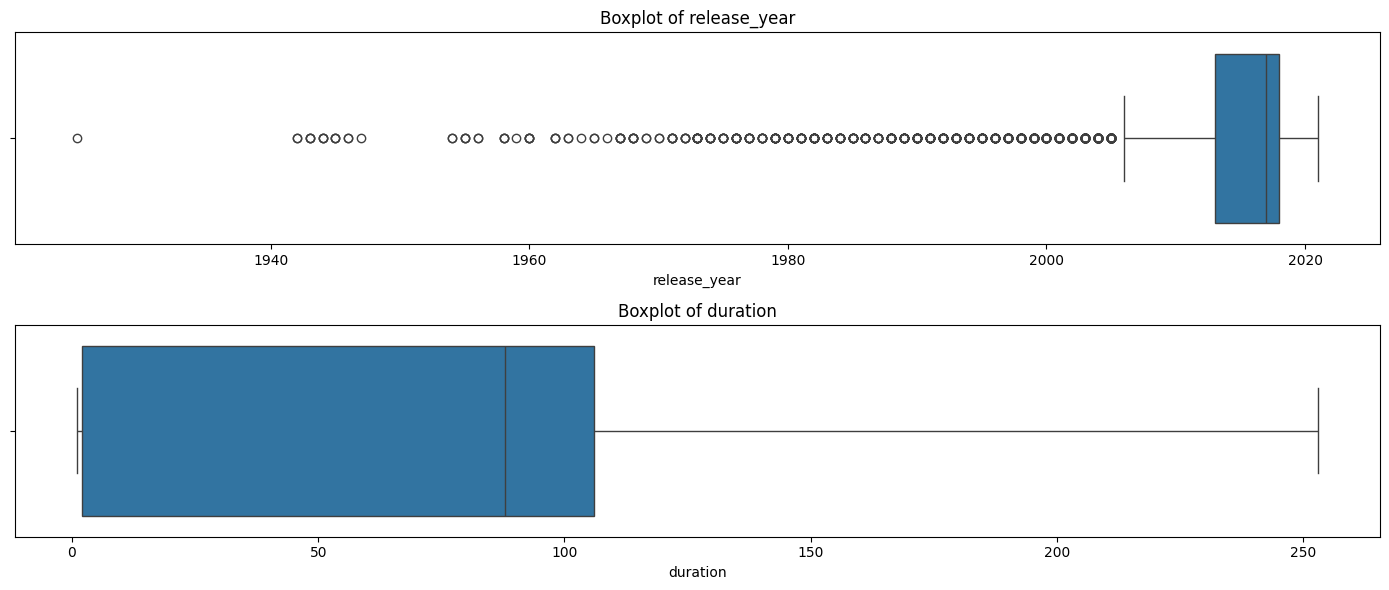

In [77]:
# Boxplots for numeric features
plt.figure(figsize=(14, 3 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [78]:
# Count by type
type_counts = df["type"].value_counts(dropna=False)
print(type_counts)

# If you only want movies and TV shows
movies = type_counts.get("Movie", 0)
tv_shows = type_counts.get("TV Show", 0)
print(f"Movies: {movies}")
print(f"TV Shows: {tv_shows}")

type
Movie      5377
TV Show    2410
Name: count, dtype: int64
Movies: 5377
TV Shows: 2410


NameError: name 'add_bar_labels' is not defined

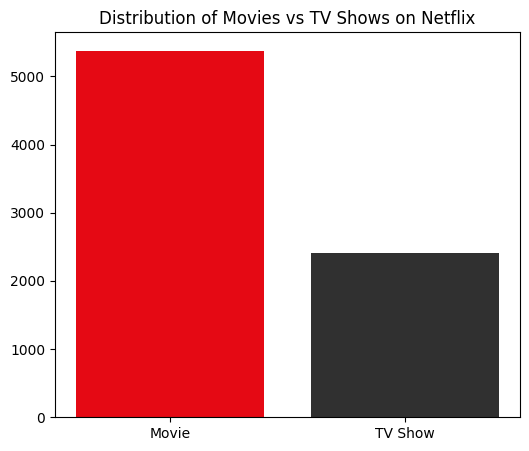

In [ ]:
plt.figure(figsize=(6, 5))

type_counts = df["type"].value_counts()
type_colors = custom_palette[:2]

plt.title ("Distribution of Movies vs TV Shows on Netflix", fontsize = 12)

bars = plt.bar(type_counts.index, type_counts.values, color=type_colors)
add_bar_labels(bars)

plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    491
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Romantic TV Shows            333
Stand-Up Comedy              329
Music & Musicals             321
Horror Movies                312
British TV Shows             232
Name: count, dtype: int64


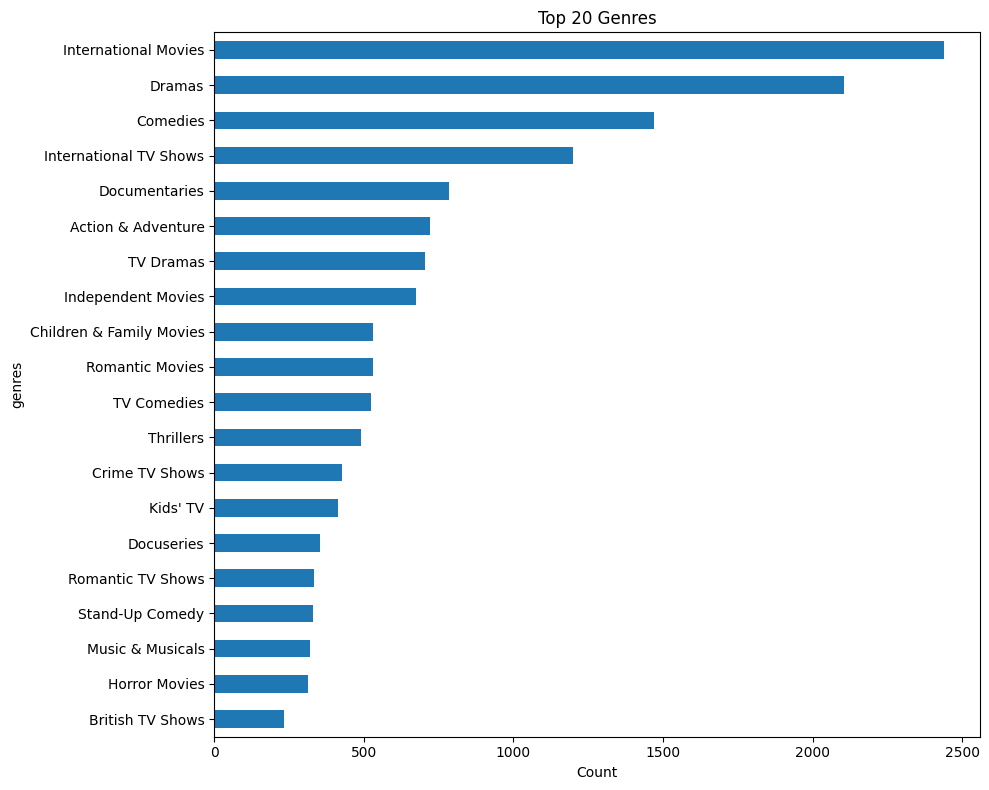

In [ ]:
# Split genres from the 'genre' column by comma
genres = (
    df['genres']
    .fillna('')
    .str.split(',')
    .explode()
    .str.strip()
)

# Remove empty values
genres = genres[genres != '']

# Count each genre separately
genre_counts = genres.value_counts()

# Display top 20 genres
print(genre_counts.head(20))

# Plot
import matplotlib.pyplot as plt

genre_counts.head(20).sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    color=custom_palette[2]
)

plt.xlabel('Count')
plt.title('Top 20 Genres')
plt.tight_layout()
plt.show()

In [96]:
df['release_year'].value_counts()

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
        ... 
1966       1
1925       1
1964       1
1947       1
1959       1
Name: count, Length: 73, dtype: int64

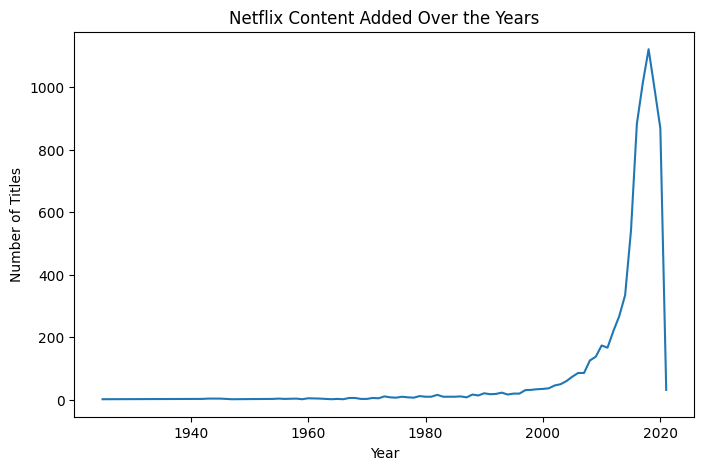

In [ ]:
plt.figure(figsize=(8,5))
df['release_year'].value_counts().sort_index().plot(kind='line', color=custom_palette[0])
plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [98]:
countries = df['country'].str.split(', ')
all_countries = countries.explode()
all_countries.value_counts().head(10)

country
United States     3296
India              990
United Kingdom     722
Unknown            507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64

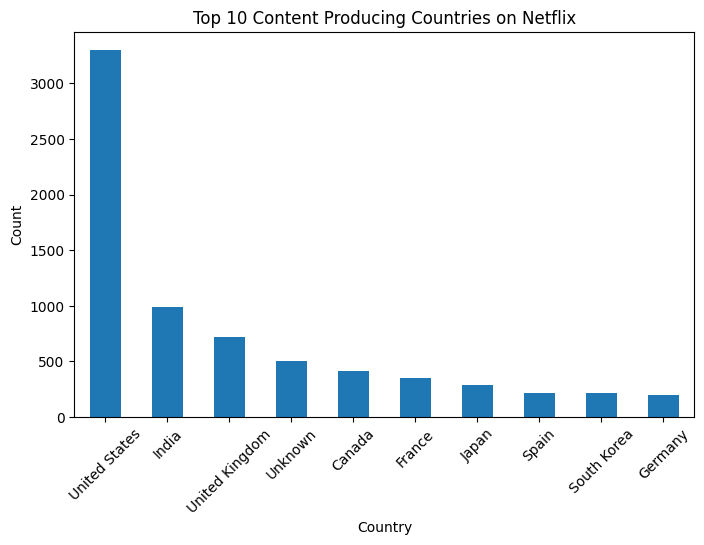

In [ ]:
plt.figure(figsize=(8,5))
all_countries.value_counts().head(10).plot(kind='bar', color=custom_palette[3])
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Key Insights from Netflix Dataset

### Content Type Distribution
Movies dominate Netflix compared to TV Shows. Their shorter duration
and diverse genres make them more accessible to a wider audience.
TV Shows on the other hand tend to lose viewer interest over
multiple seasons contributing to their lower count on the platform.

### Content by Country
The **United States** produces the highest amount of content on Netflix
by a significant margin. **India** follows as a distant second,
reflecting the growing influence of Bollywood and regional cinema
on the platform.

### Content Added Over the Years
Netflix saw a sharp rise in content additions starting from **2000**,
peaking around **2018** and gradually declining towards 2020.
This trend aligns with Netflix's aggressive content acquisition
and original production strategy during that period.

### Most Popular Genres
The three most watched genres on Netflix are:
- **International Movies** — reflecting Netflix's global audience
- **Dramas** — consistently popular across all demographics
- **Comedies** — a go-to choice for casual viewing

In [106]:
# Split genres and countries
df_expanded = df.copy()

# Separate genres
df_expanded['genres'] = df_expanded['genres'].fillna('').str.split(',')

# Separate countries
df_expanded['country'] = df_expanded['country'].fillna('').str.split(',')

# Explode both columns
df_expanded = df_expanded.explode('genres')
df_expanded = df_expanded.explode('country')

# Clean spaces
df_expanded['genres'] = df_expanded['genres'].str.strip()
df_expanded['country'] = df_expanded['country'].str.strip()

# Remove empty values
df_expanded = df_expanded[
    (df_expanded['genres'] != '') &
    (df_expanded['country'] != '')
]

# Example: movies between 2015 and 2020
filtered = df_expanded[
    (df_expanded['release_year'] >= 2015) &
    (df_expanded['release_year'] <= 2020)
]

# Count movies by year, country, and genre
movie_counts = (
    filtered
    .groupby(['release_year', 'country', 'genres'])
    .size()
    .reset_index(name='movie_count')
)

print(movie_counts.head(30))

    release_year    country                     genres  movie_count
0           2015  Argentina         Action & Adventure            1
1           2015  Argentina                   Comedies            2
2           2015  Argentina             Crime TV Shows            1
3           2015  Argentina                     Dramas            3
4           2015  Argentina              Horror Movies            1
5           2015  Argentina         Independent Movies            1
6           2015  Argentina       International Movies            4
7           2015  Argentina     International TV Shows            1
8           2015  Argentina                   Kids' TV            1
9           2015  Argentina  Spanish-Language TV Shows            2
10          2015  Argentina              Sports Movies            1
11          2015  Australia         Action & Adventure            2
12          2015  Australia   Children & Family Movies            1
13          2015  Australia              Documen

In [107]:
# Count titles added each year
year_counts = df['release_year'].value_counts().sort_index()

# Peak year
peak_year = year_counts.idxmax()

# Number of titles in peak year
peak_count = year_counts.max()

print(f"Peak Year: {peak_year}")
print(f"Number of Movies/Titles: {peak_count}")

Peak Year: 2018
Number of Movies/Titles: 1121


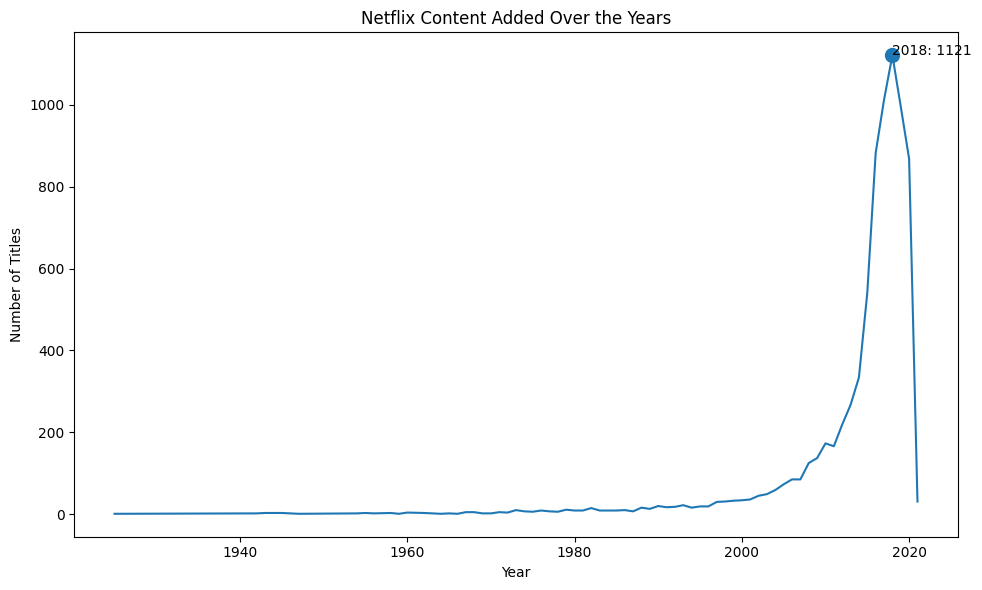

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

peak_year = year_counts.idxmax()
peak_count = year_counts.max()

plt.figure(figsize=(10, 6))

plt.plot(year_counts.index, year_counts.values, color=custom_palette[0], linewidth=2)

plt.scatter(peak_year, peak_count, s=100, color=custom_palette[1], edgecolor='black')

plt.text(
    peak_year,
    peak_count,
    f'{peak_year}: {peak_count}',
)

plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.title('Netflix Content Added Over the Years')

plt.tight_layout()
plt.show()

In [109]:
peak_year = df['release_year'].value_counts().idxmax()

peak_data = df[df['release_year'] == peak_year].copy()

peak_data['genres'] = peak_data['genres'].fillna('').str.split(',')
peak_data['country'] = peak_data['country'].fillna('').str.split(',')

peak_data = peak_data.explode('genres')
peak_data = peak_data.explode('country')

peak_data['genres'] = peak_data['genres'].str.strip()
peak_data['country'] = peak_data['country'].str.strip()

top_genre = peak_data['genres'].value_counts().idxmax()
top_genre_count = peak_data['genres'].value_counts().max()

top_country = peak_data['country'].value_counts().idxmax()
top_country_count = peak_data['country'].value_counts().max()

print(f"Peak Year: {peak_year}")
print(f"Top Genre: {top_genre} ({top_genre_count} titles)")
print(f"Top Country: {top_country} ({top_country_count} titles)")

Peak Year: 2018
Top Genre: International Movies (429 titles)
Top Country: United States (835 titles)


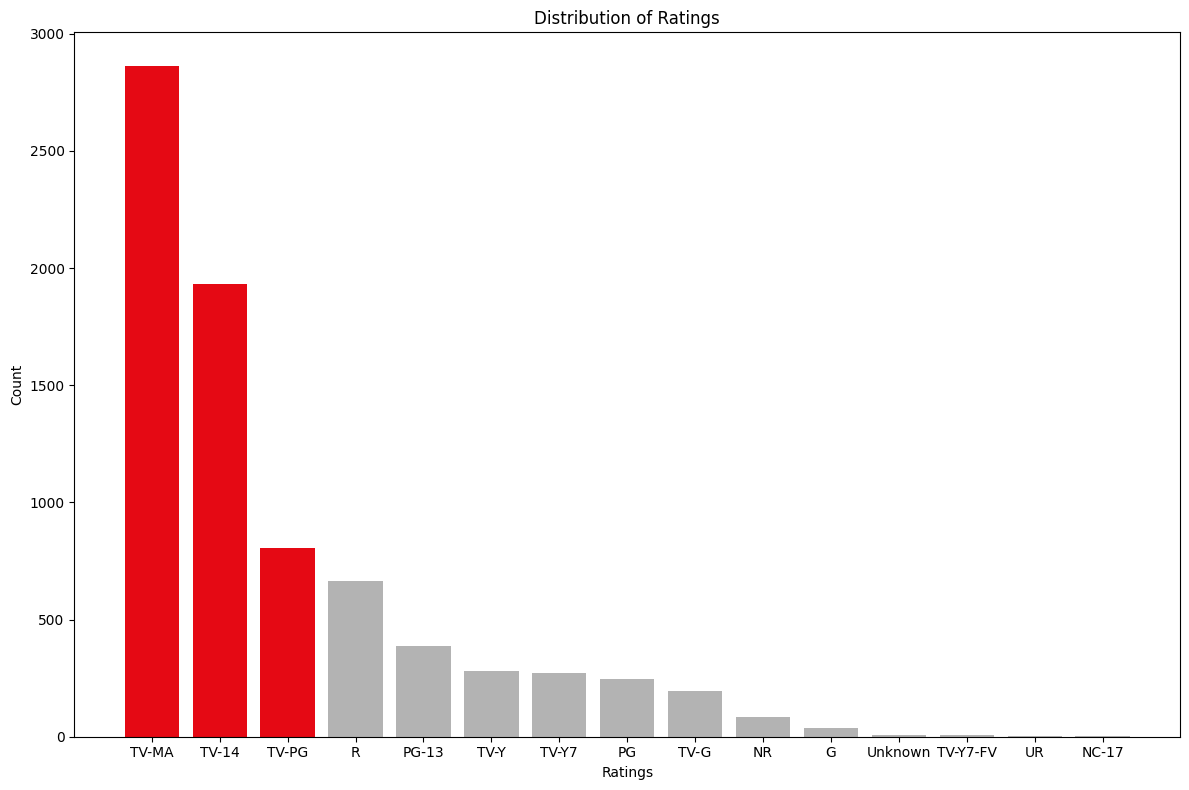

In [136]:
rating_counts = df['rating'].value_counts()

colors_rating = ["#E50914" if i < 3 else "#B3B3B3"
                 for i in range(len(rating_counts))]

plt.figure(figsize=(12,8))
plt.title("Distribution of Netflix Titles by Rating")

bars = plt.bar(rating_counts.index, rating_counts.values, color = colors_rating)

plt.xlabel('Ratings')
plt.ylabel('Count')
plt.title('Distribution of Ratings')

plt.tight_layout()
plt.show()

### Key Insights
- **TV-MA is the most dominant rating** on Netflix, confirming that
  the platform primarily targets adult audiences with content
  containing strong themes, language or violence.

- **TV-14 ranks second**, indicating a significant portion of
  teen-oriented content is also available on the platform.

- **TV-PG** represents the family-friendly segment, though it is
  considerably smaller compared to the mature content library.

### Key Takeaway
> Netflix is predominantly an adult content platform with TV-MA
> leading by a large margin, suggesting the platform prioritizes
> mature storytelling over family or children's content.